# Project Description — Regression, Classification, and Clustering

This project demonstrates the three fundamental tasks in machine learning using **synthetic datasets**:

1. **Regression**  
   - Goal: Predict a **continuous target value** from multiple input features.  
   - Approach: Train a `LinearRegression` model and evaluate with R² and RMSE.  
   - Outcome: The regression model achieved a very high R² and low RMSE, showing strong predictive ability.

2. **Classification**  
   - Goal: Predict a **categorical label (0 or 1)** based on feature inputs.  
   - Approach: Train a `LogisticRegression` model and evaluate with accuracy, confusion matrix, and precision/recall/F1 scores.  
   - Outcome: The classifier reached ~76% accuracy with balanced precision and recall across classes.

3. **Clustering**  
   - Goal: Discover **natural groupings** in unlabeled data.  
   - Approach: Apply `KMeans` with 3 clusters, then evaluate with the silhouette score and visualize results.  
   - Outcome: Clustering produced clearly separated groups with a high silhouette score (~0.84), indicating strong cluster quality.

---



**Key takeaway:**  
Regression, classification, and clustering are the building blocks of machine learning. Together, they cover most predictive and exploratory tasks, forming a strong foundation for more advanced projects.


In [1]:
print("Hello, World!")

Hello, World!


=== REGRESSION ===
R^2  : 0.986
RMSE : 15.206
Coefficients: [96.68   9.69  48.959 51.441  1.587]
Intercept   : -1.297


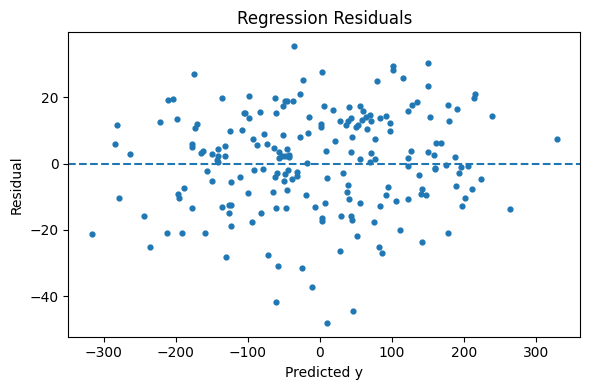


=== CLASSIFICATION ===
Accuracy: 0.760
Confusion Matrix:
 [[88 25]
 [23 64]]

Classification Report:
               precision    recall  f1-score   support

           0      0.793     0.779     0.786       113
           1      0.719     0.736     0.727        87

    accuracy                          0.760       200
   macro avg      0.756     0.757     0.756       200
weighted avg      0.761     0.760     0.760       200



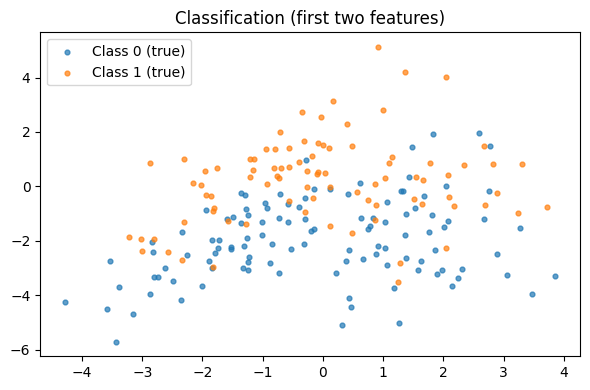


=== CLUSTERING (KMeans) ===
Silhouette score: 0.839
Cluster centers:
 [[-2.518  9.048]
 [-6.721 -6.824]
 [ 4.583  1.946]]


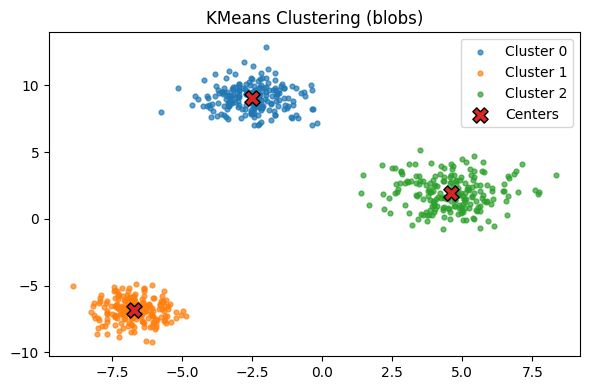

In [4]:
# ===================== Simple ML Trio: Regression / Classification / Clustering =====================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RNG_SEED = 42
np.random.seed(RNG_SEED)

# ------------------------------- 1) REGRESSION --------------------------------
X_reg, y_reg = make_regression(
    n_samples=800, n_features=5, n_informative=4, noise=15.0, random_state=RNG_SEED
)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=RNG_SEED)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

r2 = r2_score(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))   # FIXED: manual sqrt

print("=== REGRESSION ===")
print(f"R^2  : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")
print("Coefficients:", np.round(reg.coef_, 3))
print("Intercept   :", round(reg.intercept_, 3))

plt.figure(figsize=(6,4))
plt.scatter(yr_pred, yr_test - yr_pred, s=12)
plt.axhline(0, ls="--")
plt.title("Regression Residuals")
plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# ------------------------------- 2) CLASSIFICATION ----------------------------
X_clf, y_clf = make_classification(
    n_samples=800, n_features=6, n_informative=4, class_sep=1.2,
    weights=[0.55, 0.45], random_state=RNG_SEED
)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.25, random_state=RNG_SEED)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_test_s  = scaler.transform(Xc_test)

clf = LogisticRegression(max_iter=1000, random_state=RNG_SEED)
clf.fit(Xc_train_s, yc_train)
yc_pred = clf.predict(Xc_test_s)

acc = accuracy_score(yc_test, yc_pred)
print("\n=== CLASSIFICATION ===")
print(f"Accuracy: {acc:.3f}")
print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred))
print("\nClassification Report:\n", classification_report(yc_test, yc_pred, digits=3))

plt.figure(figsize=(6,4))
mask0 = yc_test==0
mask1 = yc_test==1
plt.scatter(Xc_test[mask0,0], Xc_test[mask0,1], s=12, label="Class 0 (true)", alpha=0.7)
plt.scatter(Xc_test[mask1,0], Xc_test[mask1,1], s=12, label="Class 1 (true)", alpha=0.7)
plt.title("Classification (first two features)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------- 3) CLUSTERING --------------------------------
X_clu, _ = make_blobs(
    n_samples=600, centers=3, n_features=2, cluster_std=[1.0, 1.2, 0.8], random_state=RNG_SEED
)

kmeans = KMeans(n_clusters=3, n_init=20, random_state=RNG_SEED)
labels = kmeans.fit_predict(X_clu)
centers = kmeans.cluster_centers_

sil = silhouette_score(X_clu, labels)
print("\n=== CLUSTERING (KMeans) ===")
print(f"Silhouette score: {sil:.3f}")
print("Cluster centers:\n", np.round(centers, 3))

plt.figure(figsize=(6,4))
for k in np.unique(labels):
    plt.scatter(X_clu[labels==k, 0], X_clu[labels==k, 1], s=12, label=f"Cluster {k}", alpha=0.7)
plt.scatter(centers[:,0], centers[:,1], s=120, marker="X", edgecolors="k", label="Centers")
plt.title("KMeans Clustering (blobs)")
plt.legend()
plt.tight_layout()
plt.show()


- Class 0: 88 true positives, 25 false positives.
- Class 1: 64 true positives, 23 false negatives.
- **Precision/Recall/F1:**
- Class 0: precision 0.793, recall 0.779, F1 0.786  
- Class 1: precision 0.719, recall 0.736, F1 0.727  
- Macro/weighted averages ~0.756–0.761 → reasonably balanced performance.

**Visualization note**
- The first-two-features plot shows visible overlap between classes, explaining why accuracy isn’t closer to 90%+.

**Takeaway**
- Logistic regression is performing solidly on separable-but-overlapping data.
- To improve: scale all features (done), tune C/penalty, engineer non-linear features, or try non-linear models (e.g., tree ensembles, SVM with RBF).

---

## 3) Clustering (KMeans)
**Key metrics**
- **Silhouette Score:** 0.839 — very high separation; clusters are compact and well-separated.
- **Cluster Centers (approx.):**
- Cluster 0: `(-2.518, 9.048)`
- Cluster 1: `(-6.721, -6.824)`
- Cluster 2: `(4.583, 1.946)`

**Visualization note**
- The 2D scatter shows three clearly distinct groups with minimal overlap; the learned centroids sit at the heart of each blob.

**Takeaway**
- KMeans recovered the underlying structure of the synthetic blobs nearly perfectly.
- If cluster quality were lower, typical steps are: standardize features, tune `k` via silhouette/Elbow, or try other algorithms (GMM/DBSCAN).

---

## Overall Summary
- **Regression →** Excellent fit with small random residuals; linear model is appropriate.
- **Classification →** Good, balanced performance limited by class overlap; non-linear models/features could help.
- **Clustering →** Strong, well-separated groups; KMeans works very well on blob-like data.

